In [2]:
# 自作モジュールへの変更を自動的にリロードするためのおまじない
%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import lib.S2Z as stoz
import lib.Z_model as zmodel
import lib.Useful as usf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


estimated by real value : [4.81602689e-06 5.36548760e-11 3.56871081e+00]
resonance freq : 9900818.118370911
estimated by imag value : [4.92317533e-06 5.24701063e-11 3.76048976e+00]
resonance freq : 9902423.78401365


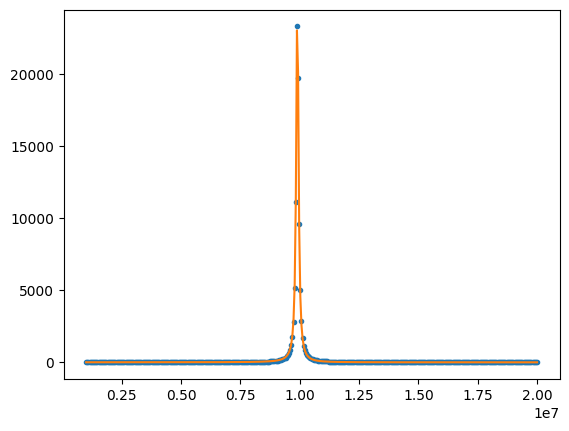

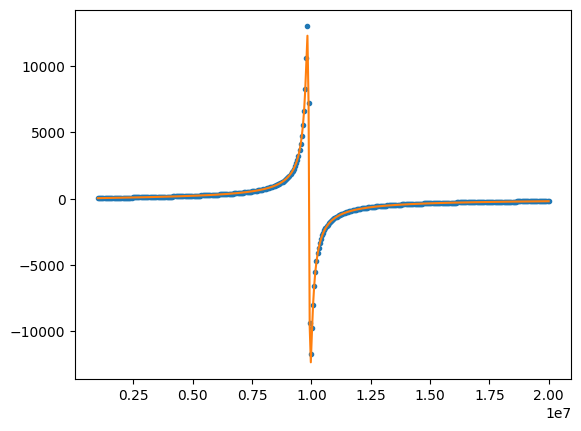

In [15]:
data = np.loadtxt("../data/LC_par_1-20MHz_2026_03_19.s1p", delimiter=" ")
freq, Z = stoz.direct(data)

plt.plot(freq, Z.real, ".")

popt, pcov = curve_fit(zmodel.L_stray_real, freq, Z.real, p0=[6e-6, 40e-12, 10])
plt.plot(freq, zmodel.L_stray_real(freq, *popt))

print("estimated by real value :", popt)
print("resonance freq :", 1 / (2 * np.pi * np.sqrt(popt[0] * popt[1])))

plt.figure()
plt.plot(freq, Z.imag, ".")

popt, pcov = curve_fit(zmodel.L_stray_imag, freq, Z.imag, p0=[6e-6, 40e-12, 10])
plt.plot(freq, zmodel.L_stray_imag(freq, *popt))

print("estimated by imag value :", popt)
print("resonance freq :", 1 / (2 * np.pi * np.sqrt(popt[0] * popt[1])))